In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from matplotlib.dates import DateFormatter
warnings.filterwarnings("ignore", category=FutureWarning)
import os
os.chdir ('D:\dataset\capstone')

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7336\1571764443.py:9: SyntaxWarning: invalid escape sequence '\d'
  os.chdir ('D:\dataset\capstone')


In [39]:
df = pd.read_csv('Drop_Employee_Performance_and_Productivity_Data.csv')
df

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,50101,Marketing,Male,42,Technician,7/9/2022,2,Bachelor,5,5250,52,12,10,4,100,1,53,2,4.38,False
1,83980,HR,Female,37,Specialist,1/28/2020,4,High School,3,5850,46,42,0,0,50,11,74,1,3.15,False
2,36186,Finance,Female,30,Technician,1/27/2018,6,Bachelor,4,4900,38,25,14,7,50,12,85,1,3.12,False
3,98346,IT,Female,47,Engineer,8/2/2019,5,High School,5,9000,41,22,11,1,0,2,2,1,2.82,False
4,34399,Legal,Male,58,Developer,9/6/2017,7,High School,4,7000,30,16,15,3,100,18,13,1,1.96,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,26651,IT,Male,54,Manager,11/1/2022,1,High School,2,7200,49,23,1,7,50,15,49,1,2.65,False
49996,68484,IT,Female,41,Analyst,9/18/2018,5,Bachelor,3,5200,32,16,15,14,25,14,63,0,1.58,True
49997,15360,Engineering,Male,58,Developer,7/7/2021,3,Bachelor,2,6000,54,4,4,7,50,2,88,1,1.95,False
49998,77199,Operations,Male,53,Developer,9/8/2018,5,Bachelor,4,7000,30,25,18,4,75,1,43,0,1.67,False


# __I. THỐNG KÊ CƠ BẢN__

In [40]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Employee_ID                  50000 non-null  int64  
 1   Department                   50000 non-null  object 
 2   Gender                       50000 non-null  object 
 3   Age                          50000 non-null  int64  
 4   Job_Title                    50000 non-null  object 
 5   Hire_Date                    50000 non-null  object 
 6   Years_At_Company             50000 non-null  int64  
 7   Education_Level              50000 non-null  object 
 8   Performance_Score            50000 non-null  int64  
 9   Monthly_Salary               50000 non-null  int64  
 10  Work_Hours_Per_Week          50000 non-null  int64  
 11  Projects_Handled             50000 non-null  int64  
 12  Overtime_Hours               50000 non-null  int64  
 13  Sick_Days       

In [42]:
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [43]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [ ]:
df.drop(columns=['Employee_ID'], inplace=True)

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,41.046500,11.201365,22.0,31.00,41.0,51.00,60.0
Years_At_Company,50000.0,4.479720,2.868281,0.0,2.00,4.0,7.00,10.0
Performance_Score,50000.0,2.995780,1.411369,1.0,2.00,3.0,4.00,5.0
Monthly_Salary,50000.0,6400.535000,1371.133496,3850.0,5250.00,6500.0,7500.00,9000.0
Work_Hours_Per_Week,50000.0,44.992120,8.952520,30.0,37.00,45.0,53.00,60.0
Projects_Handled,50000.0,24.466940,14.455063,0.0,12.00,24.0,37.00,49.0
Overtime_Hours,50000.0,14.537800,8.678350,0.0,7.00,15.0,22.00,29.0
Sick_Days,50000.0,7.021300,4.342670,0.0,3.00,7.0,11.00,14.0
Remote_Work_Frequency,50000.0,50.159500,35.375657,0.0,25.00,50.0,75.00,100.0
Team_Size,50000.0,10.010960,5.507530,1.0,5.00,10.0,15.00,19.0


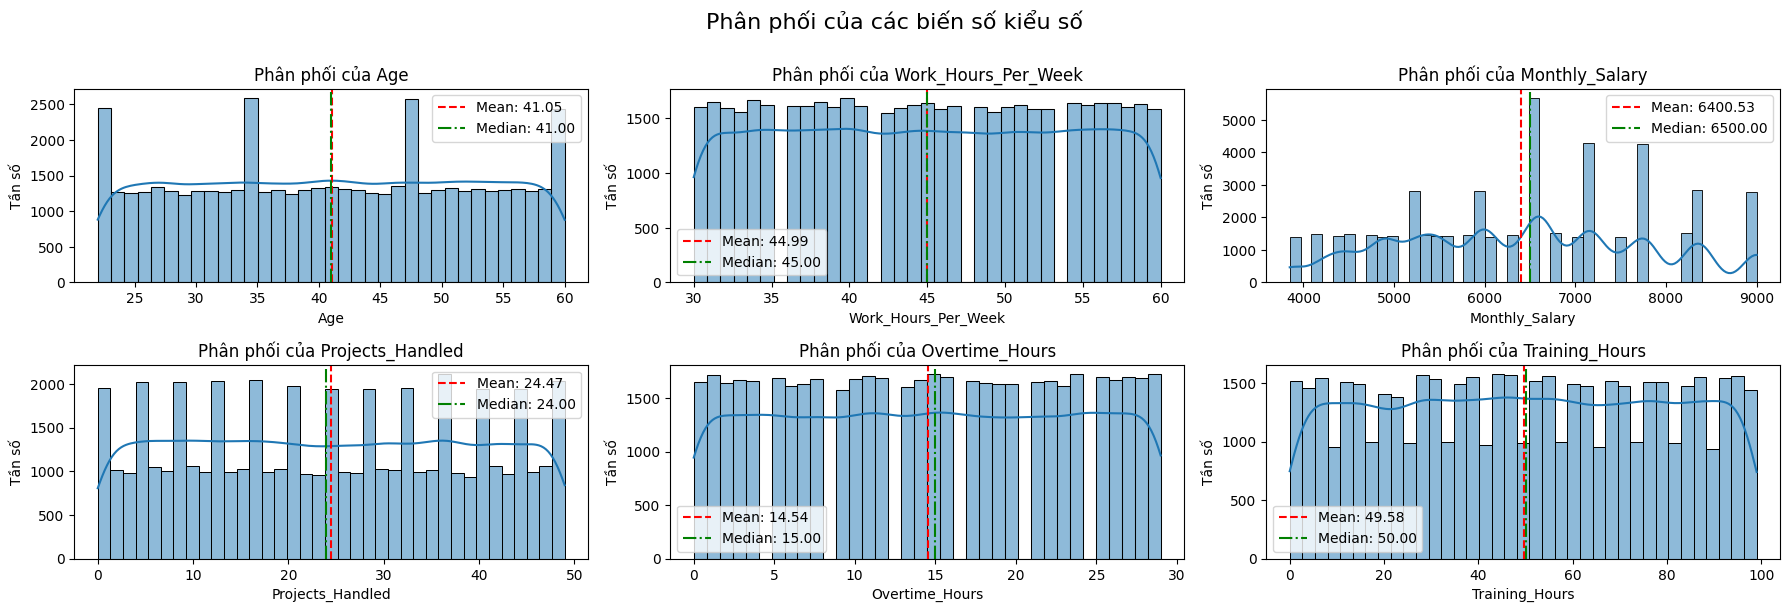

In [47]:
numerical_cols = ['Age','Work_Hours_Per_Week','Monthly_Salary', 'Projects_Handled','Overtime_Hours','Training_Hours']
fig, axes = plt.subplots(3, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Phân phối của {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tần số')
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-.', label=f'Median: {median_val:.2f}')
    axes[i].legend()
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.suptitle('Phân phối của các biến số kiểu số', fontsize=16, y=1.05)
plt.show()

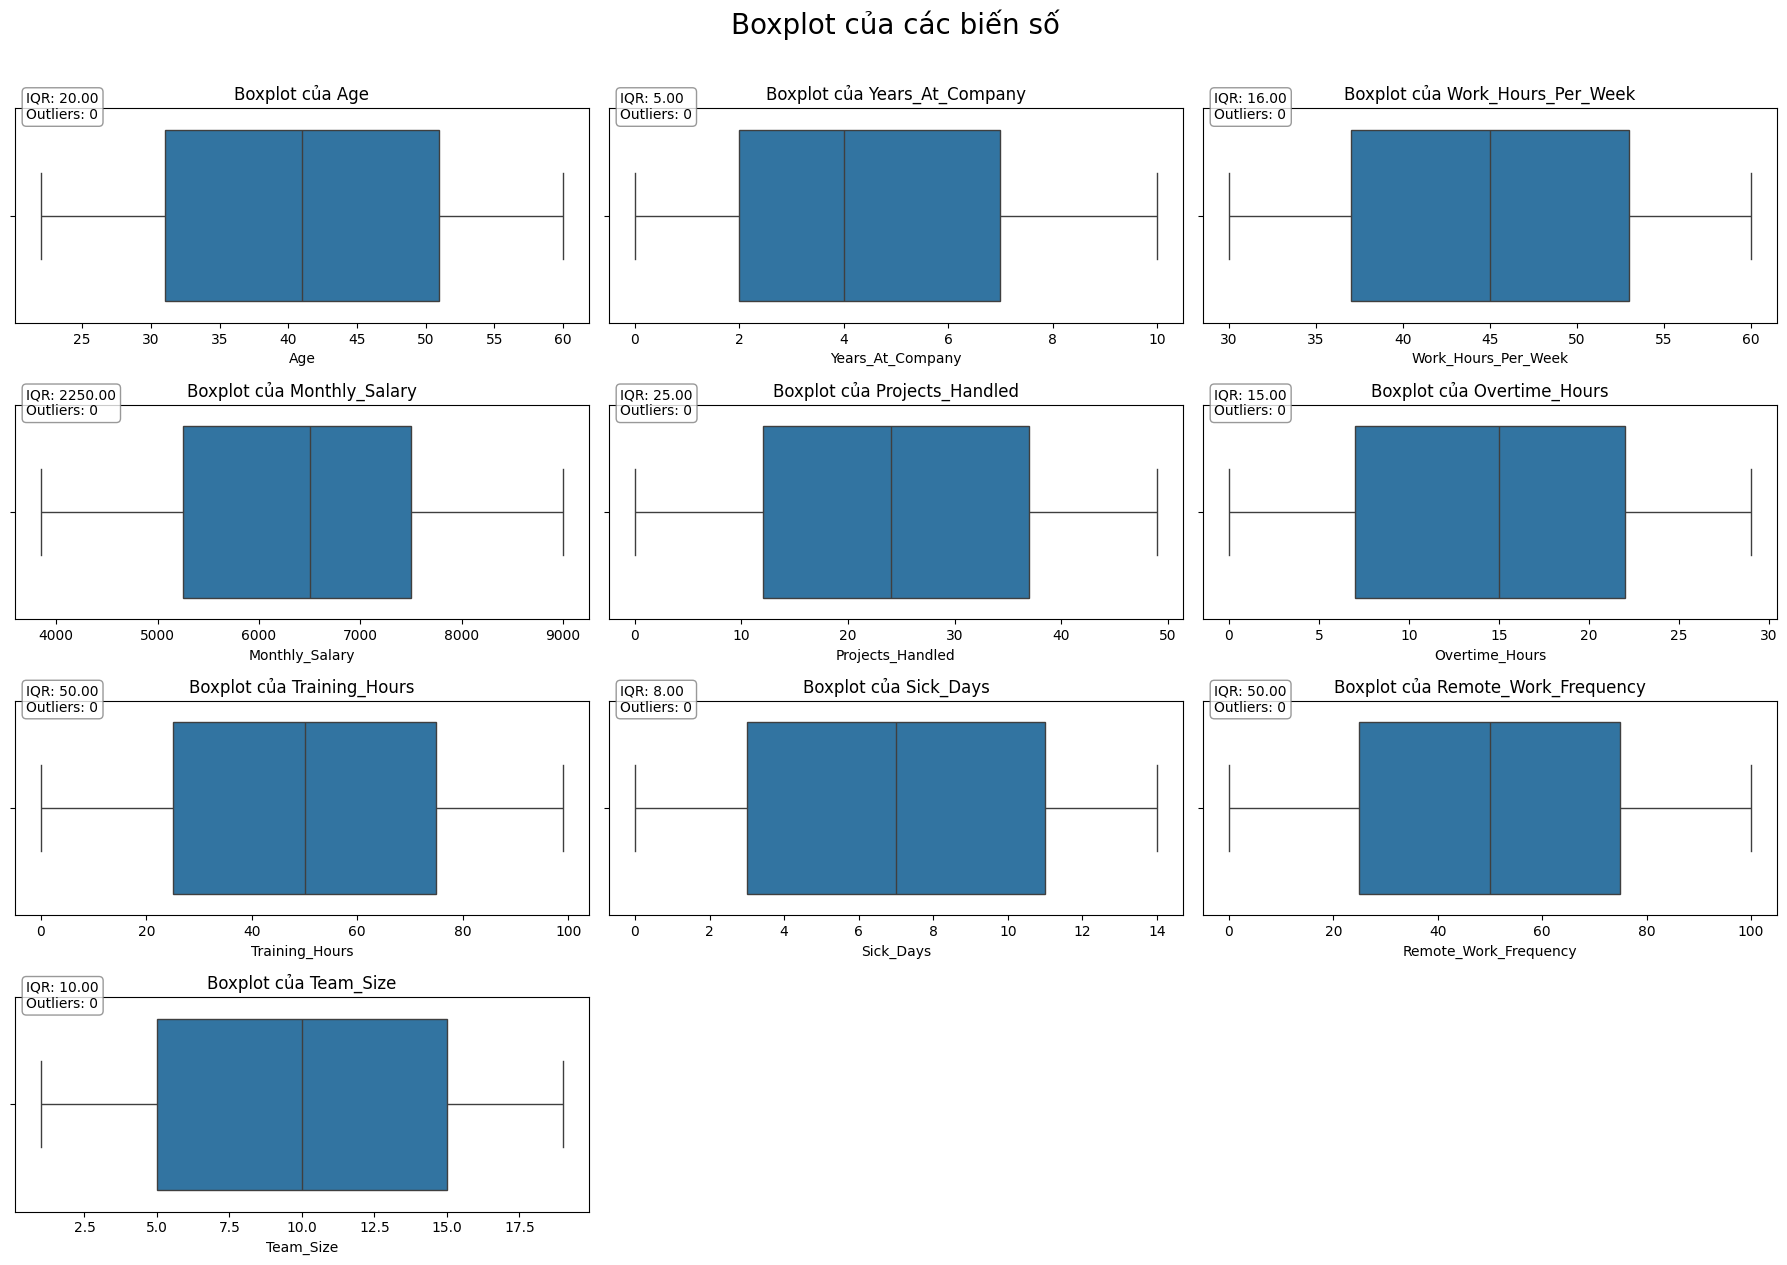

In [49]:
numerical_cols = ['Age','Years_At_Company','Work_Hours_Per_Week','Monthly_Salary', 'Projects_Handled','Overtime_Hours','Training_Hours','Sick_Days','Remote_Work_Frequency','Team_Size']
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i])
    axes[i].set_title(f'Boxplot của {col}', fontsize=12)
    axes[i].set_xlabel(col)
    
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
    
    axes[i].annotate(f'IQR: {iqr:.2f}\nOutliers: {outliers}', 
                     xy=(0.02, 0.95), xycoords='axes fraction',
                     fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.suptitle('Boxplot của các biến số', fontsize=20, y=1.05)
plt.savefig('boxplot_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# __II. KHÁM PHÁ DỮ LIỆU__

### 1. Phân tích các biến phân loại với biến mục tiêu Resigned

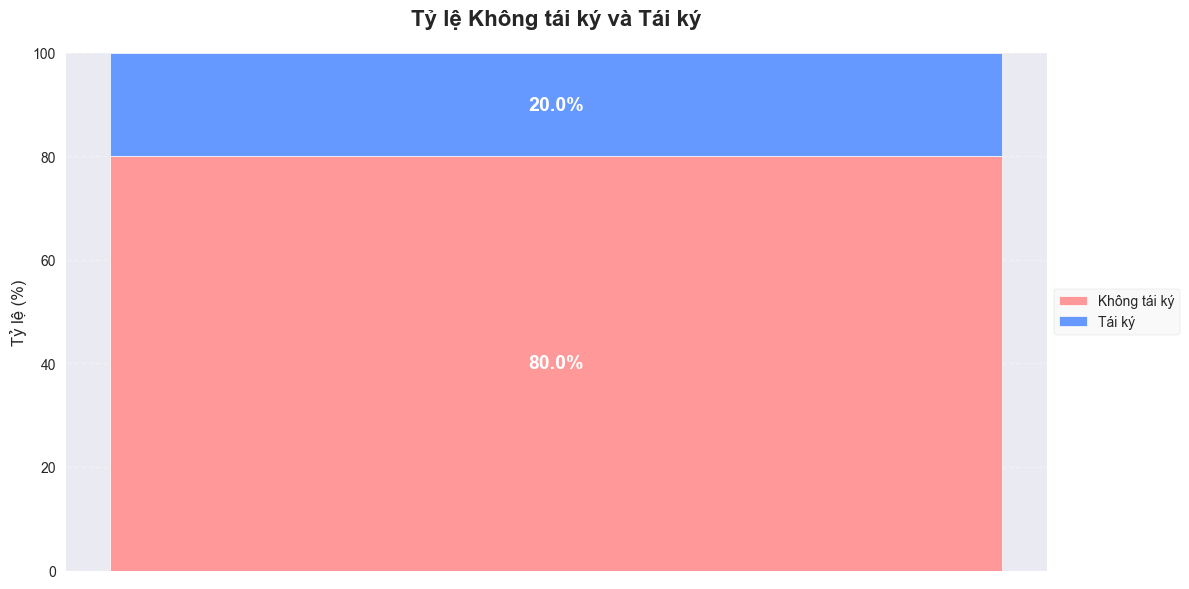

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

def create_resigned_stacked_chart(data):
    # Tính tỷ lệ
    counts = data['Resigned'].value_counts(normalize=True) * 100
    khong_tai_ky = counts.get('No', counts.get(False, counts.get(0, 0))).round(1)  # Không tái ký
    tai_ky = counts.get('Yes', counts.get(True, counts.get(1, 0))).round(1)       # Tái ký
    
    # Tạo biểu đồ
    plt.style.use('seaborn-v0_8')  # Áp dụng style seaborn đẹp mắt
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Vẽ stacked bar với màu hài hòa
    ax.bar('Resigned', khong_tai_ky, label='Không tái ký', color='#FF9999', edgecolor='white', linewidth=0.5)  # Hồng nhạt
    ax.bar('Resigned', tai_ky, bottom=khong_tai_ky, label='Tái ký', color='#6699FF', edgecolor='white', linewidth=0.5)  # Xanh biển
    
    # Thêm phần trăm với font đẹp
    for i, (val, label) in enumerate([(khong_tai_ky, khong_tai_ky/2), (tai_ky, khong_tai_ky + tai_ky/2)]):
        if val > 0:
            ax.text(0, label, f'{val:.1f}%', ha='center', va='center', fontsize=14, 
                   fontweight='bold', color='white')
    
    # Định dạng tinh tế
    ax.set_ylabel('Tỷ lệ (%)', fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=True, 
             facecolor='#f8f8f8', edgecolor='lightgray')
    ax.set_title('Tỷ lệ Không tái ký và Tái ký', pad=20, fontsize=16, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    return plt

# Gọi hàm
plot = create_resigned_stacked_chart(df)
plot.show()

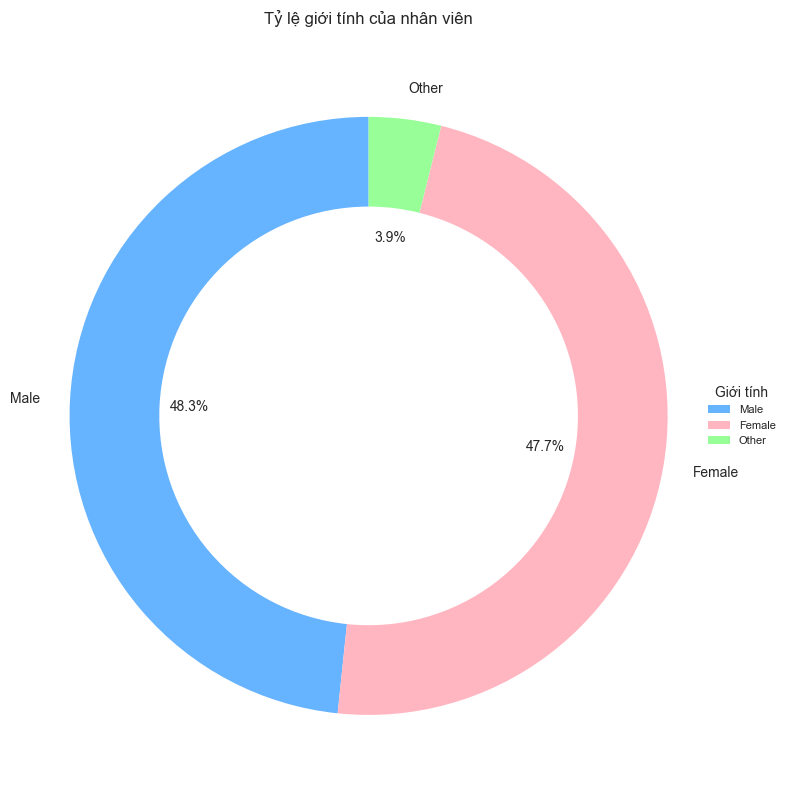

In [ ]:
def create_gender_donut_chart(data):
    # Tính tỷ lệ giới tính
    gender_counts = data['Gender'].value_counts()
    gender_percentages = (gender_counts / len(data) * 100).round(1)
    
    # Tạo danh sách màu sắc
    colors = []
    for gender in gender_percentages.index:
        if gender == 'Other':
            colors.append('#98FF98')  # Xanh lá pastel (Mint Cream) cho Other
        elif gender in ['Male', 'M', True, 1]:
            colors.append('#66b3ff')  # Xanh biển cho Male
        else:
            colors.append('#FFB6C1')  # Hồng pastel cho Female
    
    # Tạo biểu đồ donut
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(gender_percentages, labels=gender_percentages.index, autopct='%1.1f%%', 
           colors=colors, startangle=90, wedgeprops=dict(width=0.3))
    
    # Thêm tiêu đề và căn giữa
    ax.axis('equal')  # Đảm bảo biểu đồ tròn
    plt.title('Tỷ lệ giới tính của nhân viên', pad=20, fontsize=12)
    
    # Tách legend ra ngoài
    ax.legend(gender_percentages.index, title="Giới tính", loc='center left', 
              bbox_to_anchor=(1, 0.5), fontsize=8)
    
    plt.tight_layout()
    return plt

# Gọi hàm
plot = create_gender_donut_chart(df)
plot.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7336\2308551786.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(dept_resign_df['Department'], rotation=45, ha='right')  # Sử dụng tên phòng ban


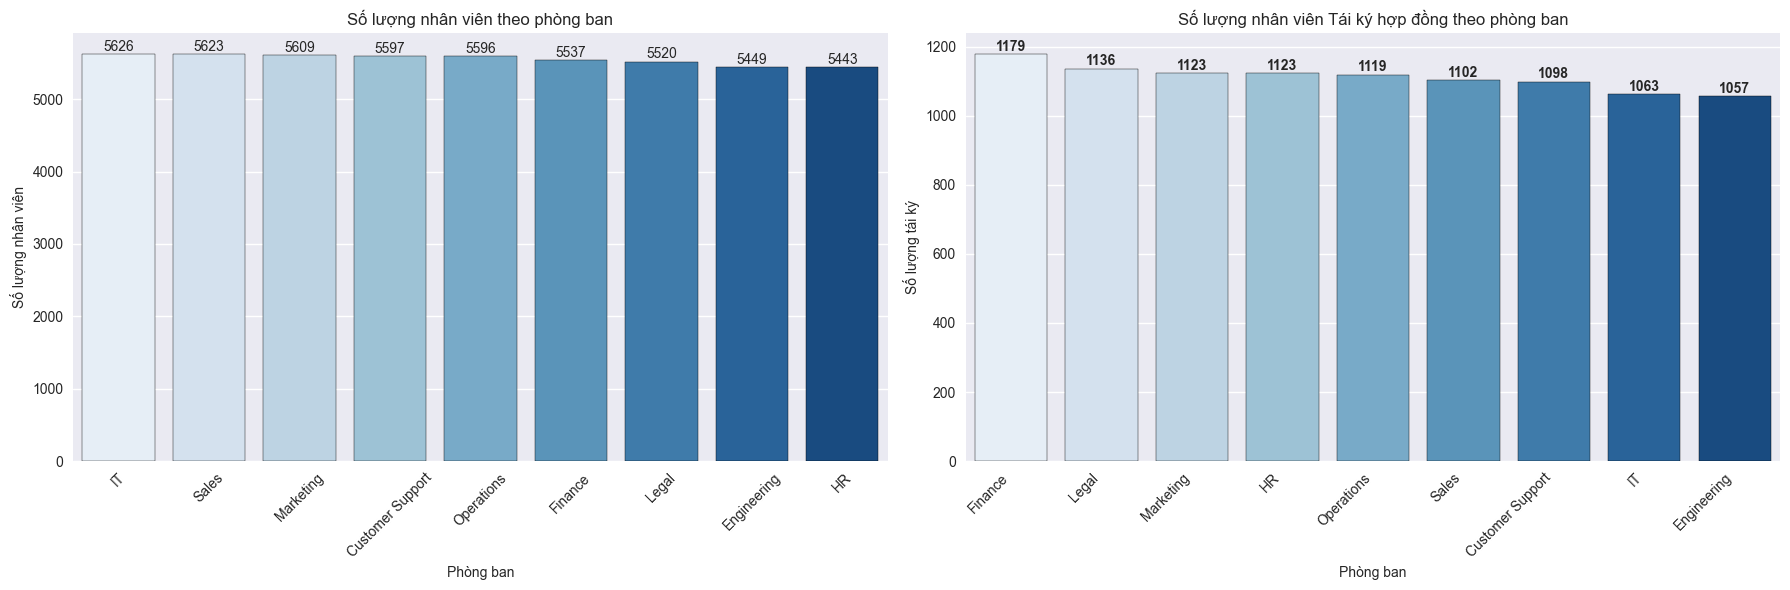

In [92]:
def create_department_charts(data):
    # Tạo lưới 1 hàng, 2 cột
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Biểu đồ 1: Số lượng nhân viên theo phòng ban
    department_counts = data['Department'].value_counts().reset_index()
    department_counts.columns = ['Department', 'Count']
    
    sns.barplot(x='Department', y='Count', data=department_counts, palette='Blues', edgecolor='black', ax=ax1)
    
    # Thêm số lượng trên đầu mỗi cột
    for i, count in enumerate(department_counts['Count']):
        ax1.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
    
    # Định dạng biểu đồ 1
    ax1.set_xlabel('Phòng ban', fontsize=10)
    ax1.set_ylabel('Số lượng nhân viên', fontsize=10)
    ax1.set_title('Số lượng nhân viên theo phòng ban', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)

    # Biểu đồ 2: Số lượng nhân viên tái ký theo phòng ban
    dept_resign = data[data['Resigned'] == True].groupby('Department').size().sort_values(ascending=False)
    dept_resign_df = dept_resign.reset_index(name='Count')  # Chuyển thành DataFrame cho sns.barplot
    
    sns.barplot(x=dept_resign_df.index, y=dept_resign_df['Count'], palette='Blues', edgecolor='black', ax=ax2)
    
    # Thêm số lượng trên đầu mỗi cột
    for i, value in enumerate(dept_resign_df['Count']):
        ax2.text(i, value + 1, str(value), ha='center', va='bottom', fontweight='bold')
    
    # Định dạng biểu đồ 2
    ax2.set_xlabel('Phòng ban', fontsize=10)
    ax2.set_ylabel('Số lượng tái ký', fontsize=10)
    ax2.set_title('Số lượng nhân viên Tái ký hợp đồng theo phòng ban', fontsize=12)
    ax2.set_xticklabels(dept_resign_df['Department'], rotation=45, ha='right')  # Sử dụng tên phòng ban
    
    # Điều chỉnh khoảng cách giữa các biểu đồ
    plt.tight_layout()
    return plt

# Gọi hàm
plot = create_department_charts(df)
plot.show()

# __III. DATA PREPROCESSING__